In [1]:
import torch.nn.functional as F
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models, datasets
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import re
import matplotlib.pyplot as plt

data_path = "/kaggle/input/datasets/sluchevskiipersii/butterflies14994/train_butterflies/train_split"
test_dir = "/kaggle/input/datasets/sluchevskiipersii/butterflies14994/test_butterflies/valid"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes num: 50

images num: 4955
avg: 99.1
min: 66, max: 139


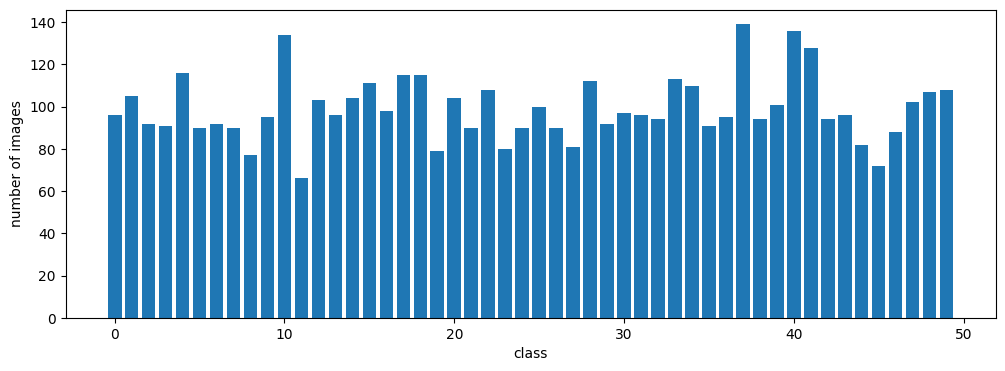

In [2]:
classes = ["class_" + str(x) for x in range(50)]
print(f"classes num: {len(classes)}")

class_counts = {}
for class_name in classes:
    class_dir = os.path.join(data_path, class_name)
    count = len([f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
    class_counts[class_name] = count

counts = list(class_counts.values())
print(f"\nimages num: {sum(counts)}")
print(f"avg: {np.mean(counts):.1f}")
print(f"min: {min(counts)}, max: {max(counts)}")

plt.figure(figsize=(12, 4))
plt.bar(range(len(classes)), counts)
plt.xlabel('class')
plt.ylabel('number of images')
plt.show()


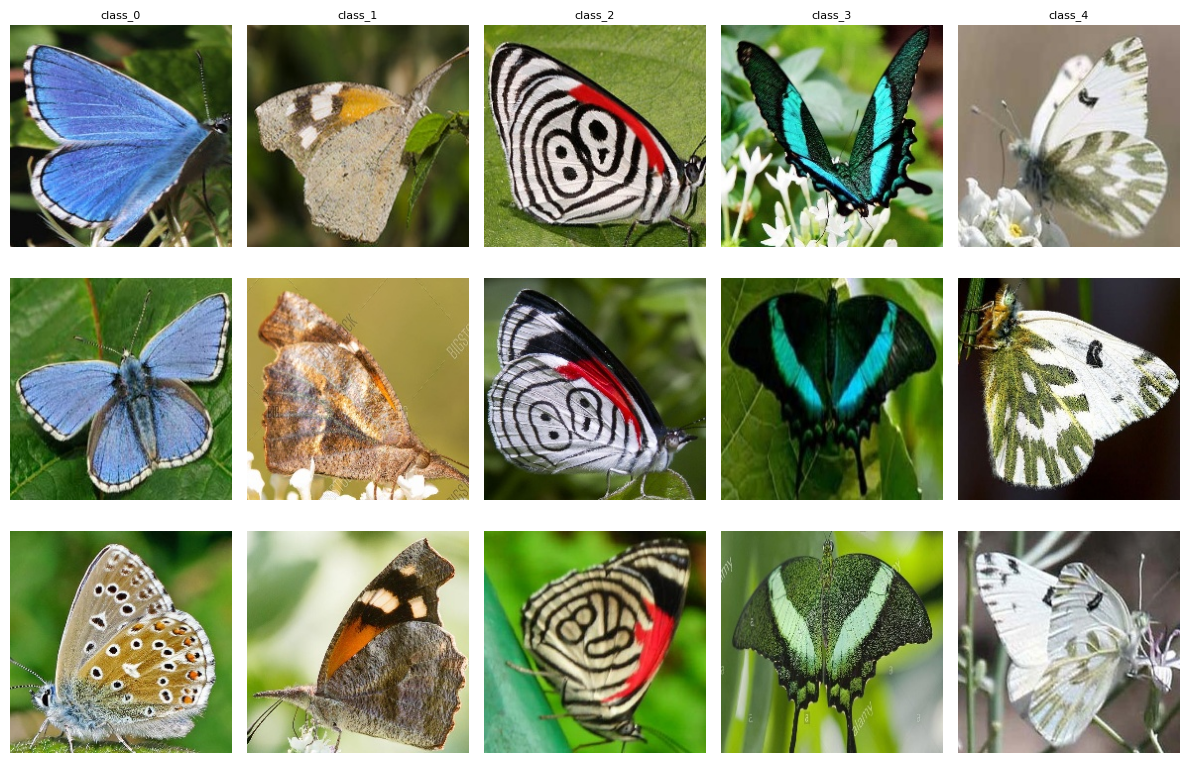

In [3]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))

for i, class_name in enumerate(classes[:5]):
    class_dir = os.path.join(data_path, class_name)
    
    img_files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    
    for j in range(3):
        img_name = img_files[j]
        img = Image.open(os.path.join(class_dir, img_name))
        axes[j, i].imshow(img)
        
        axes[j, i].axis('off')
        if j == 0:
            axes[j, i].set_title(class_name[:20], fontsize=8)

plt.tight_layout()
plt.show()

In [4]:
def plot_training_curves(train_loss, val_loss, train_acc, val_acc):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(train_loss, label='Train Loss', linewidth=2)
    axes[0].plot(val_loss, label='Val Loss', linewidth=2)
    axes[0].set_title('Loss per Epoch', fontsize=14)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(loc='upper right', fontsize=10)

    axes[1].plot(train_acc, label='Train Accuracy', linewidth=2)
    axes[1].plot(val_acc, label='Val Accuracy', linewidth=2)
    axes[1].set_title('Accuracy per Epoch', fontsize=14)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(loc='lower right', fontsize=10)

    plt.show()

In [5]:
import torch.nn.functional as F

try:
    model = models.efficientnet_b3(weights='IMAGENET1K_V1')
except:
    model = models.efficientnet_b3(pretrained=True)

print(f"basic classifier: {model.classifier}")
print(f"in_features: {model.classifier[1].in_features}")

num_classes = 50

class ImprovedClassifier(nn.Module):
    def __init__(self, in_features, num_classes, dropout_rate=0.3):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(dropout_rate * 0.7)
        self.fc3 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        return x

model.classifier = ImprovedClassifier(1536, num_classes, dropout_rate=0.3)

for param in model.parameters():
    param.requires_grad = False

blocks_to_unfreeze = 3
for param in model.features[-blocks_to_unfreeze:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

for module in model.features[-blocks_to_unfreeze:]:
    if isinstance(module, nn.BatchNorm2d):
        for param in module.parameters():
            param.requires_grad = True

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"total params: {total_params:,}")
print(f"trainable params: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"frozen params: {total_params - trainable_params:,}")

optimizer = torch.optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 166MB/s]


basic classifier: Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=1000, bias=True)
)
in_features: 1536
total params: 11,628,890
trainable params: 9,438,736 (81.2%)
frozen params: 2,190,154


In [6]:
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 300

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), ratio=(0.8, 1.2)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    
    transforms.ColorJitter(
        brightness=0.3, 
        contrast=0.2, 
        saturation=0.2, 
        hue=0.05
    ),
    transforms.RandomAdjustSharpness(sharpness_factor=1.5, p=0.3),
    
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.1),
    
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
train_dataset = datasets.ImageFolder(
    root=data_path,
    transform=train_transform
)

train_ds, val_ds = random_split(train_dataset, [0.8, 0.2])

batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [8]:
num_epochs = 30
best_val_acc = 0
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)

    for inputs, labels in train_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        train_bar.set_postfix({'loss': loss.item()})

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct_train / total_train

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]', leave=False)
        for inputs, labels in val_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model_efficientnet_b3_imp.pth')
        print(f"\n Сохранена новая лучшая модель! Accuracy: {val_acc:.2f}%")

    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"Best Val Acc: {best_val_acc:.2f}%")
    if old_lr != new_lr:
        print(f" Learning Rate изменён: {old_lr:.2e} → {new_lr:.2e}")
    else:
        print(f"Learning Rate: {old_lr:.2e}")
    print(f"{'='*50}\n")

print(" Обучение завершено!")
print(f"Лучшая точность на валидации: {best_val_acc:.2f}%")

/tmp/ipykernel_23/3452577423.py:59: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)



 Сохранена новая лучшая модель! Accuracy: 84.46%

Epoch 1/30
Train Loss: 2.1652 | Train Acc: 59.51%
Val Loss: 1.2806 | Val Acc: 84.46%
Best Val Acc: 84.46%
 Learning Rate изменён: 1.00e-05 → 9.96e-06




 Сохранена новая лучшая модель! Accuracy: 89.10%

Epoch 2/30
Train Loss: 1.3494 | Train Acc: 80.80%
Val Loss: 1.1394 | Val Acc: 89.10%
Best Val Acc: 89.10%
 Learning Rate изменён: 9.96e-06 → 9.97e-06




 Сохранена новая лучшая модель! Accuracy: 90.21%

Epoch 3/30
Train Loss: 1.2336 | Train Acc: 86.10%
Val Loss: 1.1355 | Val Acc: 90.21%
Best Val Acc: 90.21%
 Learning Rate изменён: 9.97e-06 → 9.97e-06




Epoch 4/30
Train Loss: 1.1722 | Train Acc: 87.31%
Val Loss: 1.2293 | Val Acc: 89.61%
Best Val Acc: 90.21%
 Learning Rate изменён: 9.97e-06 → 9.96e-06



...


Epoch 26/30
Train Loss: 0.8915 | Train Acc: 97.40%
Val Loss: 0.9629 | Val Acc: 94.35%
Best Val Acc: 94.85%
 Learning Rate изменён: 9.98e-06 → 9.98e-06




Epoch 27/30
Train Loss: 0.8882 | Train Acc: 97.25%
Val Loss: 0.9831 | Val Acc: 93.95%
Best Val Acc: 94.85%
 Learning Rate изменён: 9.98e-06 → 9.98e-06




Epoch 28/30
Train Loss: 0.8929 | Train Acc: 96.95%
Val Loss: 0.9670 | Val Acc: 93.84%
Best Val Acc: 94.85%
 Learning Rate изменён: 9.98e-06 → 9.98e-06




Epoch 29/30
Train Loss: 0.8852 | Train Acc: 97.25%
Val Loss: 0.9748 | Val Acc: 93.95%
Best Val Acc: 94.85%
 Learning Rate изменён: 9.98e-06 → 9.98e-06




Epoch 30/30
Train Loss: 0.8869 | Train Acc: 97.28%
Val Loss: 0.9891 | Val Acc: 94.35%
Best Val Acc: 94.85%
 Learning Rate изменён: 9.98e-06 → 9.98e-06

 Обучение завершено!
Лучшая точность на валидации: 94.85%


In [9]:
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])


test_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])


full_dataset = datasets.ImageFolder(root=data_path, transform=None)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_indices, val_indices = random_split(range(len(full_dataset)), [train_size, val_size])

class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = SubsetWithTransform(full_dataset, train_indices, transform=train_transform)
val_ds = SubsetWithTransform(full_dataset, val_indices, transform=val_transform)


batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

NameError: name 'val_transform' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def evaluate_per_class_performance(model, val_loader, class_names=None):
    """
    Оценка производительности по каждому классу
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Если имена классов не переданы, создаем стандартные
    if class_names is None:
        class_names = [f"Class_{i}" for i in range(50)]
    
    # Матрица ошибок
    cm = confusion_matrix(all_labels, all_preds)
    
    # Per-class метрики
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    per_class_precision = []
    per_class_recall = []
    per_class_f1 = []
    
    for i in range(len(class_names)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        per_class_precision.append(precision)
        per_class_recall.append(recall)
        per_class_f1.append(f1)
    
    # Создаем DataFrame с результатами
    results_df = pd.DataFrame({
        'Class': class_names,
        'Accuracy': per_class_acc,
        'Precision': per_class_precision,
        'Recall': per_class_recall,
        'F1-Score': per_class_f1,
        'Samples': cm.sum(axis=1)
    })
    
    # Сортируем по accuracy
    results_df = results_df.sort_values('Accuracy').reset_index(drop=True)
    
    return results_df, cm

# Загружаем лучшую модель (если нужно)
model.load_state_dict(torch.load('best_model_efficientnet_b3_imp.pth'))

# Оцениваем производительность
results_df, confusion_mtx = evaluate_per_class_performance(model, val_loader)

# Показываем худшие классы
print("="*80)
print("🔴 ХУДШИЕ 10 КЛАССОВ (по accuracy):")
print("="*80)
print(results_df.head(10).to_string(index=True, float_format=lambda x: f'{x:.2%}'))

print("\n" + "="*80)
print("🟢 ЛУЧШИЕ 10 КЛАССОВ (по accuracy):")
print("="*80)
print(results_df.tail(10).to_string(index=True, float_format=lambda x: f'{x:.2%}'))

print("\n" + "="*80)
print("📊 ОБЩАЯ СТАТИСТИКА:")
print("="*80)
print(f"Средняя accuracy: {results_df['Accuracy'].mean():.2%}")
print(f"Медианная accuracy: {results_df['Accuracy'].median():.2%}")
print(f"Стандартное отклонение: {results_df['Accuracy'].std():.2%}")
print(f"Классов с accuracy < 50%: {(results_df['Accuracy'] < 0.5).sum()}")
print(f"Классов с accuracy > 80%: {(results_df['Accuracy'] > 0.8).sum()}")